<a href="https://colab.research.google.com/github/snehapadgaonkar/beat2bit/blob/main/notebooks/04_quantization_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 3 & 4: Quantization and Pruning
This notebook takes the trained baseline FP32 model and applies
Magnitude Pruning and INT8 Post-Training Quantization.

In [1]:
!pip install numpy matplotlib scipy pandas tensorflow tensorflow-model-optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 7.8 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
import numpy as np
import os
import tensorflow_model_optimization as tfmot

### 1. Load the Dataset and Baseline Model

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import zipfile
import json
import tensorflow_model_optimization as tfmot

X_train = np.load('/content/drive/MyDrive/data/processed/X_train.npy')
X_test = np.load('/content/drive/MyDrive/data/processed/X_test.npy')
y_test = np.load('/content/drive/MyDrive/data/processed/y_test.npy')

model_path = '/content/drive/MyDrive/models/baseline_cnn.keras'

# Manually extract model config to handle version incompatibility
model_config = None

# The .keras file is a zip archive, we can extract its contents
with zipfile.ZipFile(model_path, 'r') as zf:
    # Read config.json
    with zf.open('config.json') as f:
        model_config = json.load(f)

# Process the model_config to remove 'batch_shape' and 'optional' from InputLayer
# and fix dtype configuration for all layers, also remove quantization_config
def clean_layer_config(config):
    if isinstance(config, dict):
        # Fix dtype policy
        if 'dtype' in config and isinstance(config['dtype'], dict) and \
           config['dtype'].get('class_name') == 'DTypePolicy' and \
           'config' in config['dtype'] and 'name' in config['dtype']['config']:
            config['dtype'] = config['dtype']['config']['name']

        if config.get('class_name') == 'InputLayer':
            # Clean arguments for InputLayer
            if 'config' in config and isinstance(config['config'], dict):
                if 'batch_shape' in config['config']:
                    config['config']['batch_input_shape'] = config['config'].pop('batch_shape')
                config['config'].pop('optional', None)

        # Remove 'quantization_config' if present, as it can cause issues during deserialization
        # if the layer itself doesn't explicitly support it in its __init__ method
        if 'config' in config and isinstance(config['config'], dict):
            config['config'].pop('quantization_config', None)

        # Recursively clean nested configurations (e.g., in Sequential or Functional models)
        for key, value in config.items():
            config[key] = clean_layer_config(value)
    elif isinstance(config, list):
        for i, item in enumerate(config):
            config[i] = clean_layer_config(item)
    return config

# Clean the entire model configuration
cleaned_model_config = clean_layer_config(model_config)

# Create a new model from the cleaned configuration
# Use tfmot.quantization.keras.quantize_scope() to handle quantization-aware layers
with tfmot.quantization.keras.quantize_scope():
    baseline_model = tf.keras.models.model_from_config(cleaned_model_config)

# Load weights from the original .keras file
baseline_model.load_weights(model_path)

fp32_size = os.path.getsize(model_path)
print(f"Loaded Baseline FP32 Model. Size: {fp32_size / 1024:.2f} KB")

Loaded Baseline FP32 Model. Size: 74.79 KB


### 2. Magnitude Pruning
We define a pruning schedule to achieve 70% sparsity (setting 70% of weights to zero).

In [15]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

# Load y_train here as it was missing from the data loading step
y_train = np.load('/content/drive/MyDrive/data/processed/y_train.npy')

# Calculate end step based on batch size and epochs
batch_size = 128
epochs = 4
validation_split = 0.1
num_images = X_train.shape[0] * (1 - validation_split)
end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs

pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
          initial_sparsity=0.20,
          final_sparsity=0.70,
          begin_step=0,
          end_step=end_step)
}

pruned_model = prune_low_magnitude(baseline_model, **pruning_params)
pruned_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fine-tune the pruned model
import tempfile
logdir = tempfile.mkdtemp()
callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]

print("Fine-tuning pruned model...")
pruned_model.fit(
    X_train, y_train, # Note: y_train must be loaded in the actual run
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=callbacks,
    verbose=1
)

# Strip pruning wrappers to get a clean model
model_for_export = tfmot.sparsity.keras.strip_pruning(pruned_model)

Fine-tuning pruned model...
Epoch 1/4
359/359 [==============================] - 15s 31ms/step - loss: 0.1391 - accuracy: 0.9610 - val_loss: 0.3653 - val_accuracy: 0.9124
Epoch 2/4
359/359 [==============================] - 8s 23ms/step - loss: 0.1601 - accuracy: 0.9535 - val_loss: 0.3609 - val_accuracy: 0.9212
Epoch 3/4
359/359 [==============================] - 11s 30ms/step - loss: 0.1668 - accuracy: 0.9521 - val_loss: 0.3609 - val_accuracy: 0.9096
Epoch 4/4
359/359 [==============================] - 10s 28ms/step - loss: 0.1502 - accuracy: 0.9580 - val_loss: 0.3619 - val_accuracy: 0.9122


### 3. INT8 Quantization + TFLite Conversion
We quantize the stripped pruned model down to 8-bit integers.

In [16]:
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(500):
        yield [tf.cast(input_value, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

quantized_model_path = '/content/drive/MyDrive/models/model_pruned_quantized.tflite'
with open(quantized_model_path, 'wb') as f:
    f.write(tflite_model_quant)

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


### 4. Compression Results

In [17]:
int8_size = os.path.getsize(quantized_model_path)
print("\n=== Size Comparison ===")
print(f"Original FP32 Model Size : {fp32_size / 1024:.2f} KB")
print(f"Pruned+INT8 Model Size   : {int8_size / 1024:.2f} KB")
print(f"Compression Ratio        : {fp32_size / int8_size:.2f}x smaller!")


=== Size Comparison ===
Original FP32 Model Size : 74.79 KB
Pruned+INT8 Model Size   : 10.86 KB
Compression Ratio        : 6.89x smaller!


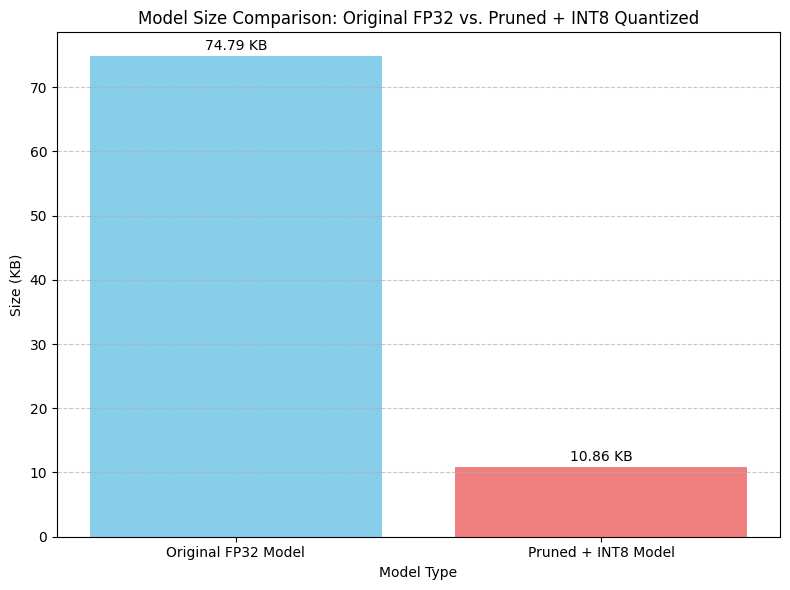

In [18]:
import matplotlib.pyplot as plt

# Data for plotting
model_names = ['Original FP32 Model', 'Pruned + INT8 Model']
sizes_kb = [fp32_size / 1024, int8_size / 1024]

# Create the bar graph
plt.figure(figsize=(8, 6))
plt.bar(model_names, sizes_kb, color=['skyblue', 'lightcoral'])

# Add labels and title
plt.xlabel('Model Type')
plt.ylabel('Size (KB)')
plt.title('Model Size Comparison: Original FP32 vs. Pruned + INT8 Quantized')

# Add value labels on top of bars
for i, size in enumerate(sizes_kb):
    plt.text(i, size + 0.5, f'{size:.2f} KB', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Helper function to calculate Sensitivity and Positive Predictivity
def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    positive_predictivity = tp / (tp + fp) if (tp + fp) > 0 else 0
    return sensitivity, positive_predictivity

# 1. Evaluate Baseline FP32 Model
# The baseline_model was loaded from config and weights, so it needs to be compiled.
baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
_, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
baseline_predictions = (baseline_model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
baseline_sensitivity, baseline_pos_predictivity = calculate_metrics(y_test, baseline_predictions)

# 2. Evaluate Pruned FP32 Model (after stripping pruning wrappers)
# model_for_export is the stripped pruned model. It needs to be compiled before evaluation.
model_for_export.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
_, pruned_accuracy = model_for_export.evaluate(X_test, y_test, verbose=0)
pruned_predictions = (model_for_export.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
pruned_sensitivity, pruned_pos_predictivity = calculate_metrics(y_test, pruned_predictions)

# 3. Evaluate Quantized INT8 TFLite Model
interpreter = tf.lite.Interpreter(model_content=tflite_model_quant)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale, input_zero_point = input_details['quantization']
output_scale, output_zero_point = output_details['quantization']

def quantize_input(data):
    # Ensure input data is float32 for scaling, then convert to the required int type
    return (data / input_scale + input_zero_point).astype(input_details['dtype'])

def dequantize_output(data):
    # Dequantize output data from int to float
    return (data.astype(np.float32) - output_zero_point) * output_scale

tflite_predictions_raw = []
for i in range(len(X_test)):
    input_data = X_test[i:i+1] # Get one sample
    quantized_input_data = quantize_input(input_data)

    interpreter.set_tensor(input_details['index'], quantized_input_data)
    interpreter.invoke()
    tflite_output = interpreter.get_tensor(output_details['index'])
    dequantized_output = dequantize_output(tflite_output)

    # Assuming binary classification with a single output neuron
    tflite_predictions_raw.append(dequantized_output[0][0])

tflite_predictions_raw = np.array(tflite_predictions_raw)
tflite_predicted_classes = (tflite_predictions_raw > 0.5).astype(int) # Apply threshold for binary classification
tflite_accuracy = np.mean(tflite_predicted_classes == y_test)
tflite_sensitivity, tflite_pos_predictivity = calculate_metrics(y_test, tflite_predicted_classes)

# Create a DataFrame for comparison with updated column names and metrics
data = {
    'Model': ['Original FP32', 'Pruned FP32', 'Pruned + INT8 Quantized'],
    'Accuracy': [baseline_accuracy, pruned_accuracy, tflite_accuracy],
    'Sensitivity': [baseline_sensitivity, pruned_sensitivity, tflite_sensitivity],
    'Positive Predictivity': [baseline_pos_predictivity, pruned_pos_predictivity, tflite_pos_predictivity],
    'Reported Size (KB)': [fp32_size / 1024, fp32_size / 1024, int8_size / 1024] # Pruned model is still FP32 in size
}

df = pd.DataFrame(data)
print(df.to_markdown(index=False, floatfmt=".4f"))

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


| Model                   |   Accuracy |   Sensitivity |   Positive Predictivity |   Reported Size (KB) |
|:------------------------|-----------:|--------------:|------------------------:|---------------------:|
| Original FP32           |     0.9181 |        0.3808 |                  0.7689 |              74.7949 |
| Pruned FP32             |     0.9181 |        0.3808 |                  0.7689 |              74.7949 |
| Pruned + INT8 Quantized |     0.8995 |        0.1868 |                  0.6805 |              10.8594 |


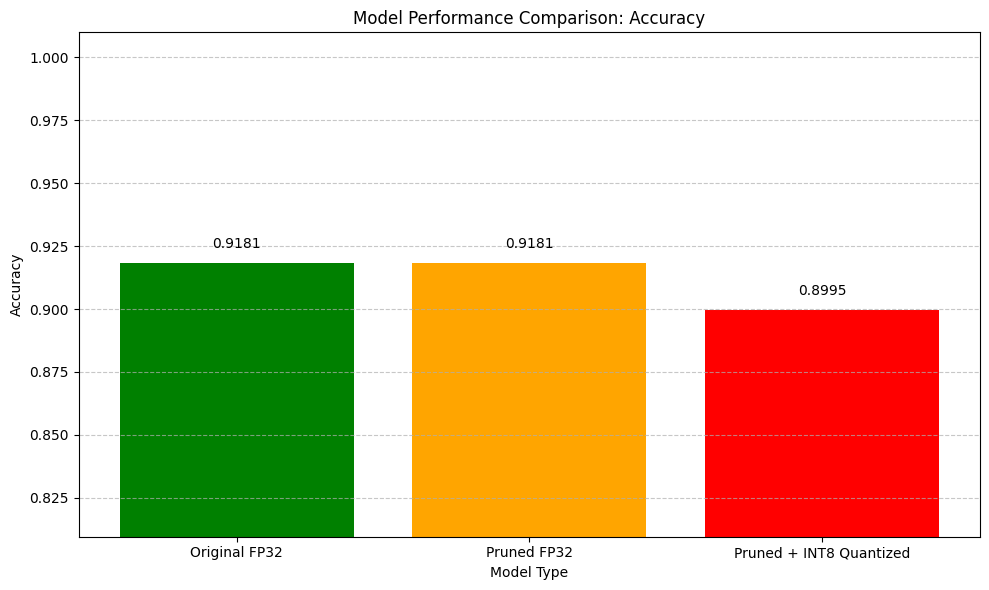

In [23]:
import matplotlib.pyplot as plt

# Data for plotting
model_labels = ['Original FP32', 'Pruned FP32', 'Pruned + INT8 Quantized']
accuracies = [baseline_accuracy, pruned_accuracy, tflite_accuracy]

# Create the bar graph
plt.figure(figsize=(10, 6))
plt.bar(model_labels, accuracies, color=['green', 'orange', 'red'])

# Add labels and title
plt.xlabel('Model Type')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison: Accuracy')
plt.ylim(min(accuracies) * 0.9, max(accuracies) * 1.1) # Adjust y-axis limit for better visualization

# Add accuracy values on top of bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()